# Assignment 9

Welcome to the assignment for week 9.

## Task 9: YOLO - You Only Look Once

This week, we want you to implement the core YOLO algorithm for object detection. Feel free to stay close to the lecture and/or use information from the web. You will pass the assignment, if we see the main YOLO algorithm characteristics in your code. A well performing model is not the only factor for passing the assignment.

### Task 9.1 Prepare Multi-Object Detection Dataset (COCO)

* Load and prepare the COCO dataset - for example using the PyTorch library directly: https://pytorch.org/vision/0.19/generated/torchvision.datasets.CocoDetection.html
* Prepare the sample and target for later use and show some samples. **(RESULT)**

In [136]:
# imports
import torch
from torchvision.datasets import CocoDetection
from pycocotools.coco import COCO
from torchvision import transforms
import torch.nn as nn
import matplotlib.pyplot as plt
import cv2
from torchvision.ops import nms


# ...

loading annotations into memory...
Done (t=1.56s)
creating index...
index created!
loading annotations into memory...
Done (t=23.30s)
creating index...
index created!
loading annotations into memory...
Done (t=0.69s)
creating index...
index created!
loading annotations into memory...
Done (t=37.07s)
creating index...
index created!
[{'segmentation': [[37.31, 373.02, 57.4, 216.61, 67.44, 159.21, 77.49, 113.29, 91.84, 86.03, 123.41, 84.59, 162.15, 96.07, 215.25, 86.03, 261.17, 70.24, 285.56, 68.81, 337.22, 68.81, 411.84, 93.2, 454.89, 107.55, 496.5, 255.35, 513.72, 262.53, 552.47, 292.66, 586.0, 324.23, 586.0, 381.63, 586.0, 449.08, 586.0, 453.38, 578.3, 616.97, 518.03, 621.27, 444.84, 624.14, 340.09, 625.58, 136.32, 625.58, 1.43, 632.75, 7.17, 555.26, 5.74, 414.64]], 'area': 275709.8110500001, 'iscrowd': 0, 'image_id': 285, 'bbox': [1.43, 68.81, 584.57, 563.94], 'category_id': 23, 'id': 587562}]


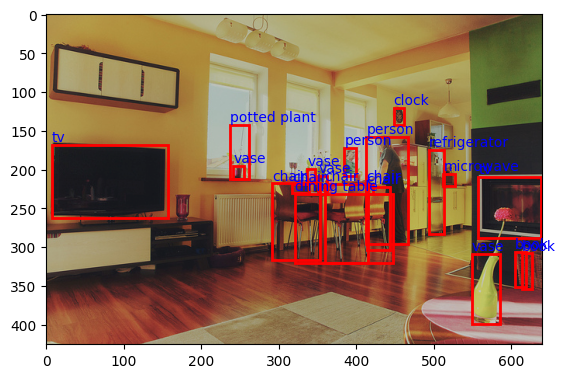

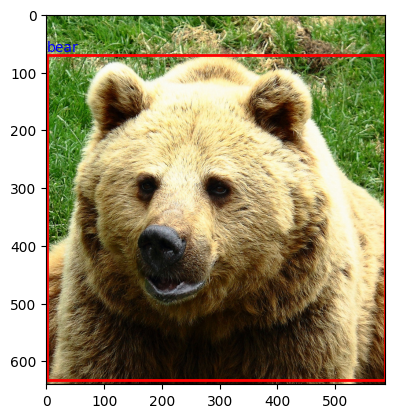

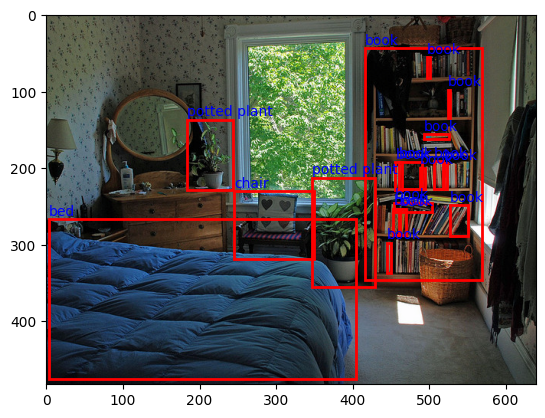

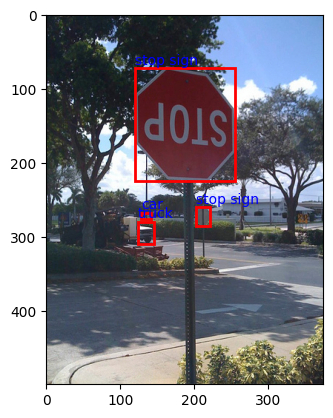

In [137]:
test_data_path = r"C:\Users\Massi\OneDrive\Desktop\Computer VIssion\COCO\val2017\val2017"
annotation_path_test = r"C:\Users\Massi\OneDrive\Desktop\Computer VIssion\COCO\annotations_trainval2017\annotations\instances_val2017.json"
annotation_path_train = r"C:\Users\Massi\OneDrive\Desktop\Computer VIssion\COCO\annotations_trainval2017\annotations\instances_train2017.json"
train_data_path = r"C:\Users\Massi\OneDrive\Desktop\Computer VIssion\COCO\train2017"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

test_data = CocoDetection(root = test_data_path, annFile = annotation_path_test, transform = transform)
train_data = CocoDetection(root = train_data_path, annFile = annotation_path_train, transform = transform)
test_name = COCO(annotation_path_test)
train_name = COCO(annotation_path_train)

image, target = test_data[1]
print (target)
for i in range (4):
    image, target = test_data[i]
    image_np = image.permute(1, 2, 0).numpy() 
    image_np = (image_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    image_np = (image_np * 255).astype('uint8')
    for obj in target:
        bbox = obj["bbox"]
        category_id = obj["category_id"]
        category_name = test_name.cats[category_id]["name"]
        x, y, w, h = bbox
        rect = plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        plt.gca().add_patch(rect)
        plt.text(x, y - 5, category_name, color="blue", fontsize=10, backgroundcolor="none")
    plt.imshow(image_np)
    plt.show()

### Task 9.2 Build the YOLO pipeline

* Setup a model class for your model. **(RESULT)**
* Build a training loop and the necessary additional functions for training. **(RESULT)**
* Run at least a few training iterations on your machine. **(RESULT)**

In [138]:
architecture_config = [
    (7, 64, 2, 3),
    "M",
    (3, 192, 1, 1),
    "M",
    (1, 128, 1, 0),
    (3, 256, 1, 1),
    (1, 256, 1, 0),
    (3, 512, 1, 1),
    "M",
    [(1, 256, 1, 0), (3, 512, 1, 1), 4],
    (1, 512, 1, 0),
    (3, 1024, 1, 1),
    "M",
    [(1, 512, 1, 0), (3, 1024, 1, 1), 2],
    (3, 1024, 1, 1),
    (3, 1024, 2, 1),
    (3, 1024, 1, 1),
    (3, 1024, 1, 1),
]


In [139]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.LeakyReLU(0.1)
    
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

In [ ]:
class Yolov1(nn.Module):
    def __init__(self, in_channels = 3, **kwargs):
        super(Yolov1, self).__init__()
        self.architecture = architecture_config
        self.in_channels = in_channels
        self.darknet = self._create_conv_layers(self.architecture)
        self.fcs = self._create_fcs(**kwargs)
    
    def forward(self, x):
        x = self.darknet(x)
        x = torch.flatten(x, start_dim=1)
        return self.fcs(x)
    
    def _create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if type(x) == tuple:
                layers += [
                    CNNBlock(
                    in_channels, x[1], kernel_size=x[0], stride=x[2], padding=x[3],
                    )
                ]

                in_channels = x[1]

            elif type(x) == str:
                layers += [nn.MaxPool2d(kernel_size = 2, stride = 2)]

            elif type(x) == list:
                conv1 = x[0]
                conv2 = x[1]
                num_repeats = x[2]

                for _ in range(num_repeats):
                    layers += [
                        CNNBlock(
                            in_channels,
                            conv1[1],
                            kernel_size = conv1[0],
                            stride = conv1[2],
                            padding = conv1[3],
                        )
                    ]
                    layers += [
                        CNNBlock(
                            conv1[1],
                            conv2[1],
                            kernel_size = conv2[0],
                            stride = conv2[2],
                            padding = conv2[3],
                        )
                    ]

                    in_channels = conv2[1]
        return nn.Sequential(*layers) # (*layers) unpacks individualy the list
        
    def _create_fcs(self, split_size, num_boxes, num_classes):
        S, B, C = split_size, num_boxes, num_classes
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 4096),
            nn.Dropout(0.0),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, S * S * (C + B * 5)),
        )
    
def test(split_size = 7, num_boxes = 2, num_classes = 80):
    model = Yolov1(split_size = split_size, num_boxes = num_boxes, num_classes = num_classes)
    x = torch.randn((2, 3, 448, 448))
    print(model(x).shape)

    
test()

torch.Size([2, 1470])


In [141]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):

    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2

    if box_format == "corners":
        box1_x1 = boxes_preds[..., 0:1]
        box1_y1 = boxes_preds[..., 1:2]
        box1_x2 = boxes_preds[..., 2:3]
        box1_y2 = boxes_preds[..., 3:4]  # (N, 1)
        box2_x1 = boxes_labels[..., 0:1]
        box2_y1 = boxes_labels[..., 1:2]
        box2_x2 = boxes_labels[..., 2:3]
        box2_y2 = boxes_labels[..., 3:4]

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    # .clamp(0) is for the case when they do not intersect
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)

    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

In [145]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=80):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction = "sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B*5)
        iou_b1 = intersection_over_union(predictions[..., (self.C+1):(self.C+5)], target[..., (self.C+1):(self.C+5)])
        iou_b2 = intersection_over_union(predictions[..., (self.C+6):(self.C+10)], target[..., (self.C+1):(self.C+5)])
        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)

        iou_maxes, bestbox = torch.max(ious, dim=0)
        exists_box = target[..., self.C].unsqueeze(3)

        box_predictions = exists_box * (
            (
                bestbox * predictions[..., (self.C+6):(self.C+10)]
                + (1 - bestbox) * predictions[..., (self.C+1):(self.C+5)]
            )
        )

        box_targets = exists_box * target[..., (self.C+1):(self.C+5)]


        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2),
        )

        pred_box = (
            bestbox * predictions[..., (self.C+5):(self.C+6)] + (1 - bestbox) * predictions[..., (self.C):(self.C+1)]
        )

        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * target[..., (self.C):(self.C+1)]),
        )

        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., (self.C):(self.C+1)], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., (self.C):(self.C+1)], start_dim=1),
        )

        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., (self.C+5):(self.C+6)], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., (self.C):(self.C+1)], start_dim=1)
        )

        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :(self.C)], end_dim=-2,),
            torch.flatten(exists_box * target[..., :(self.C)], end_dim=-2,),
        )

        loss = (
            self.lambda_coord * box_loss  # first two rows in paper
            + object_loss  # third row in paper
            + self.lambda_noobj * no_object_loss  # forth row
            + class_loss  # fifth row
        )

        return loss

In [146]:
def normalize_bbox(bbox, image_width, image_height):
    x, y, width, height = bbox
    normalized_width = width / image_width
    normalized_height = height / image_height
    return [x, y, normalized_width, normalized_height]

In [149]:
from tqdm import tqdm
import torch.optim as optim
from torch.utils.data import DataLoader

seed = 123
torch.manual_seed(seed)

LEARNING_RATE = 2e-5
DEVICE = "cuda" if torch.cuda.is_available else "cpu"
BATCH_SIZE = 16
EPOCHS = 5
NUM_WORKERS = 2

def train_fn(train_loader, model, optimizer, loss_fn):
    loop = tqdm(train_loader, leave=True)
    mean_loss = []

    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = loss_fn(out, y)
        mean_loss.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update progress bar
        loop.set_postfix(loss=loss.item())

    print(f"Mean loss was {sum(mean_loss)/len(mean_loss)}")

model = Yolov1(split_size=7, num_boxes=2, num_classes=80).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = YoloLoss()

train_loader = DataLoader(train_data,BATCH_SIZE, num_workers = NUM_WORKERS, shuffle = True)
test_loader = DataLoader(test_data,BATCH_SIZE, num_workers = NUM_WORKERS, shuffle = True)

for epoch in range(EPOCHS):
    train_fn(train_loader, model, optimizer, loss_fn)

  0%|          | 0/7393 [02:40<?, ?it/s]


KeyboardInterrupt: 

### Task 9.3 Show your results

* Plot at least two detection results on COCO samples your model has not seen. **(RESULT)**

In [148]:
# code here

## Congratz, you made it! :)